# Input Cost EDA: PyPSA-Earth Technology Cost Assumptions

Exploratory analysis of the **input** cost assumptions that feed this model, distinct from
`BESS_Cost_Structure_Analysis.ipynb`, which audits **output** costs from the solved networks.

Source: `technology-data v0.13.2`, year 2050, as retrieved and processed by PyPSA-Earth's
`retrieve_cost_data` / `process_cost_data` rules into `costs_2050.csv` (raw, long-format,
one row per technology-parameter pair) and `costs_2050_elec.csv` (pivoted, one row per
technology, `capital_cost`/`marginal_cost` computed as PyPSA actually uses them).

These files are **not** run-specific, both `baseline_bess_2050_overnight` and
`baseline_no_bess_2050_overnight` share identical copies (same `technology_data_version`
and cost `year`), so this notebook loads a single copy rather than comparing Run A vs Run B.

**What "relevant" means below:** technology-data ships ~297 technologies covering the full
PyPSA-Earth sector-coupled catalogue (hydrogen, shipping, industry, ...), most of which this
electricity-only Senegal model never touches. `RELEVANT_CARRIERS` in the config cell is the
subset actually enabled in `config.baseline_senegal_2050_overnight.yaml`
(`electricity.conventional_carriers`, `renewable_carriers`, `extendable_carriers`), so
Sections 3-5 and 7-8 focus on those, while Sections 2 and 6 use the full catalogue for context.

## 0. Setup & Configuration

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

PALETTE = {
    "blue_teal": "#0B4F6C", "amber": "#E8A33D", "slate": "#4A6572",
    "burgundy": "#7A3B46", "green": "#4B7A63",
}
CATEGORY_COLORS = {"renewable": PALETTE["green"], "thermal": PALETTE["burgundy"], "storage": PALETTE["blue_teal"]}

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "font.size": 12, "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "figure.autolayout": True,
})

FIG_DIR = Path("figures/input_costs")
FIG_DIR.mkdir(exist_ok=True, parents=True)

def savefig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")

def crf(rate, lifetime):
    '''Capital recovery factor, converts an overnight cost into an annuity.'''
    if rate == 0:
        return 1 / lifetime
    return rate / (1 - (1 + rate) ** (-lifetime))


In [47]:
COST_RAW_PATH = "resources/baseline_bess_2050_overnight/costs_2050.csv"
COST_ELEC_PATH = "resources/baseline_bess_2050_overnight/costs_2050_elec.csv"

# Matches config.baseline_senegal_2050_overnight.yaml: electricity.conventional_carriers
# + renewable_carriers + extendable_carriers.{Generator,Store}
RELEVANT_CARRIERS = ["solar", "onwind", "hydro", "CCGT", "OCGT", "oil", "coal", "biomass",
                     "battery", "battery inverter"]
CATEGORY = {
    "solar": "renewable", "onwind": "renewable", "hydro": "renewable",
    "CCGT": "thermal", "OCGT": "thermal", "oil": "thermal", "coal": "thermal", "biomass": "thermal",
    "battery": "storage", "battery inverter": "storage",
}


## 1. Load & Overview

In [48]:
raw = pd.read_csv(COST_RAW_PATH)
elec = pd.read_csv(COST_ELEC_PATH, index_col=0)

missing = [c for c in RELEVANT_CARRIERS if c not in elec.index]
assert not missing, f"RELEVANT_CARRIERS not found in cost file: {missing}"

sub = elec.loc[RELEVANT_CARRIERS].copy()
sub["category"] = sub.index.map(CATEGORY)

print(f"Raw (long) format: {raw.shape[0]} rows, {raw.technology.nunique()} technologies, "
      f"{raw.parameter.nunique()} distinct parameters")
print(f"Pivoted (wide) format: {elec.shape[0]} technologies x {elec.shape[1]} columns")
print(f"\nModel-relevant subset ({len(RELEVANT_CARRIERS)} technologies):")
sub[["category", "investment", "FOM", "VOM", "efficiency", "lifetime", "capital_cost", "marginal_cost"]]


Raw (long) format: 1231 rows, 294 technologies, 58 distinct parameters
Pivoted (wide) format: 297 technologies x 60 columns

Model-relevant subset (10 technologies):


,category,investment,FOM,VOM,efficiency,lifetime,capital_cost,marginal_cost
technology,,,,,,,,
solar,renewable,408717.4,2.0676,0.0106,1.000,40.0,30129.873172,0.010000
onwind,renewable,1019137.5,1.1775,1.2857,1.000,30.0,94128.969871,0.015000
hydro,renewable,2274817.7,1.0000,0.0000,0.900,80.0,182698.734592,0.000000
CCGT,thermal,846577.3,3.2500,4.2329,0.600,25.0,100158.998230,45.179567
OCGT,thermal,435818.0,1.8023,4.7620,0.430,25.0,45252.515808,61.896884
oil,thermal,355562.5,2.4095,6.3493,0.350,25.0,39078.280467,157.523871
coal,thermal,3827162.9,1.3100,3.2612,0.356,40.0,337208.027448,30.098840
biomass,thermal,2337611.6,4.5269,0.0000,0.468,30.0,294201.051170,15.828205
battery,storage,NaN,NaN,NaN,NaN,NaN,61075.839080,0.000000


saved figures/input_costs/01_data_completeness.png


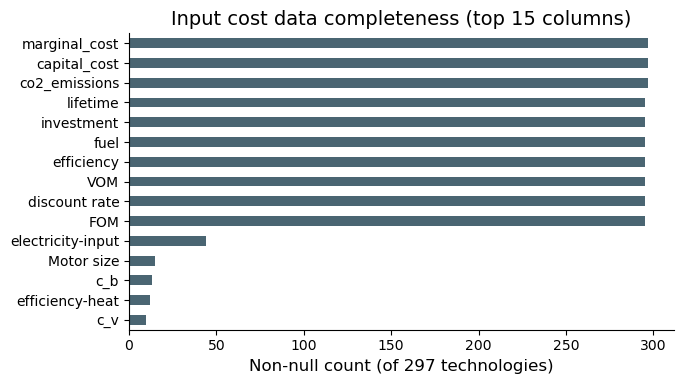

In [49]:
# Data completeness: most of the 60 columns are sector-specific attributes (biomass %, H2
# storage geometry, ...) that are NaN for nearly everything except their one relevant tech.
# The columns actually driving this electricity-only model are the ones with near-full coverage.
nn = elec.notna().sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 4))
nn.plot(kind="barh", ax=ax, color=PALETTE["slate"])
ax.set_xlabel(f"Non-null count (of {len(elec)} technologies)")
ax.set_title("Input cost data completeness (top 15 columns)")
ax.invert_yaxis()
savefig(fig, "01_data_completeness")
plt.show()


## 2. Landscape: Where This Model's Technologies Sit in the Full Catalogue

`technology-data` ships assumptions for the whole PyPSA-Earth sector-coupled scope. These two
plots show the full distribution of investment cost and lifetime across all technologies,
with this model's carriers marked, so you can say whether e.g. "coal" is a cheap or expensive
entry relative to the entire catalogue, not just relative to the other 9 carriers you use.

saved figures/input_costs/02_landscape_investment.png


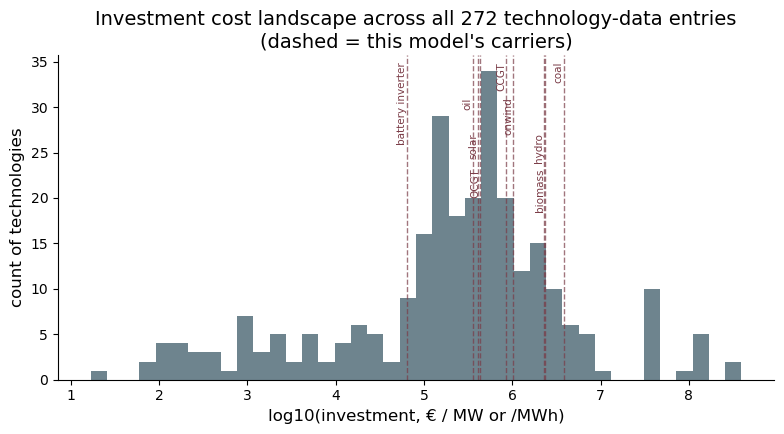

In [50]:
fig, ax = plt.subplots(figsize=(8, 4.5))
inv = elec["investment"].dropna()
inv = inv[inv > 0]
ax.hist(np.log10(inv), bins=40, color=PALETTE["slate"], alpha=0.8)

carrier_x = {c: np.log10(elec.loc[c, "investment"]) for c in RELEVANT_CARRIERS
             if pd.notna(elec.loc[c, "investment"]) and elec.loc[c, "investment"] > 0}
ymax = ax.get_ylim()[1]
for i, (carrier, x) in enumerate(sorted(carrier_x.items(), key=lambda kv: kv[1])):
    ax.axvline(x, color=PALETTE["burgundy"], linestyle="--", linewidth=1, alpha=0.7)
    # stagger label height so close-together carriers (e.g. hydro/biomass) don't overlap
    y = ymax * (0.98 - 0.11 * (i % 4))
    ax.annotate(carrier, (x, y), rotation=90, fontsize=7.5, ha="right", va="top", color=PALETTE["burgundy"])
ax.set_xlabel("log10(investment, € / MW or /MWh)")
ax.set_ylabel("count of technologies")
ax.set_title(f"Investment cost landscape across all {len(inv)} technology-data entries\n(dashed = this model's carriers)")
savefig(fig, "02_landscape_investment")
plt.show()


saved figures/input_costs/03_landscape_lifetime.png


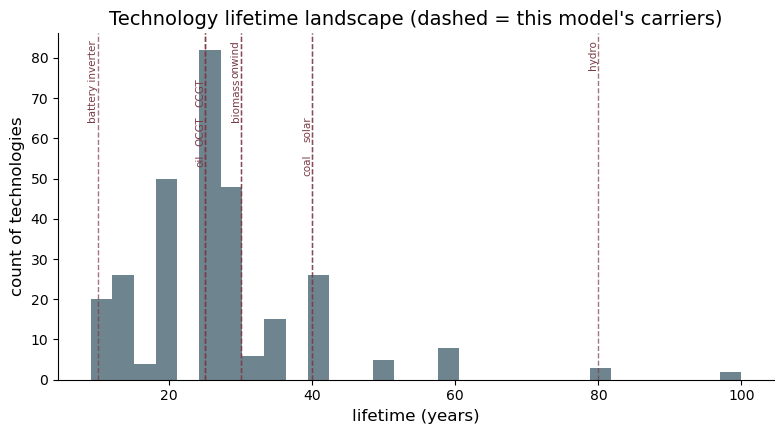

In [51]:
fig, ax = plt.subplots(figsize=(8, 4.5))
lt = elec["lifetime"].dropna()
ax.hist(lt, bins=30, color=PALETTE["slate"], alpha=0.8)

carrier_x = {c: elec.loc[c, "lifetime"] for c in RELEVANT_CARRIERS if pd.notna(elec.loc[c, "lifetime"])}
ymax = ax.get_ylim()[1]
for i, (carrier, x) in enumerate(sorted(carrier_x.items(), key=lambda kv: kv[1])):
    ax.axvline(x, color=PALETTE["burgundy"], linestyle="--", linewidth=1, alpha=0.7)
    # stagger label height so technologies sharing the same lifetime (e.g. CCGT/OCGT/oil = 25y) don't overlap
    y = ymax * (0.98 - 0.11 * (i % 4))
    ax.annotate(carrier, (x, y), rotation=90, fontsize=7.5, ha="right", va="top", color=PALETTE["burgundy"])
ax.set_xlabel("lifetime (years)")
ax.set_ylabel("count of technologies")
ax.set_title("Technology lifetime landscape (dashed = this model's carriers)")
savefig(fig, "03_landscape_lifetime")
plt.show()


## 3. Head-to-Head: This Model's 10 Carriers

One bar chart per cost parameter, sorted descending, colored by category (green =
renewable, burgundy = thermal, blue = storage).

saved figures/input_costs/04_investment.png


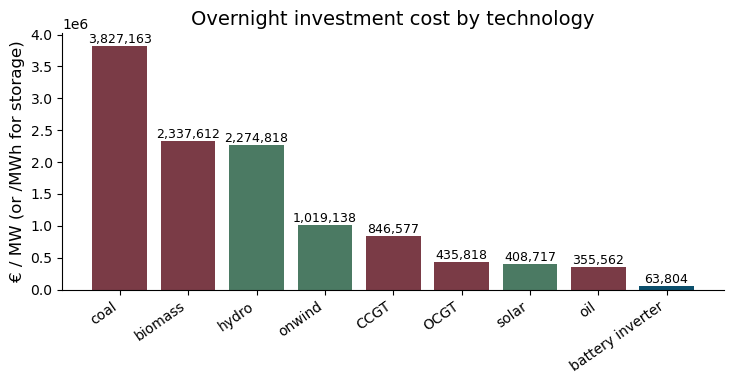

In [52]:
def bar_compare(col, ylabel, title, fname, fmt="{:.2f}"):
    vals = sub[col].astype(float)
    order = vals.sort_values(ascending=False).index
    colors = [CATEGORY_COLORS[CATEGORY[c]] for c in order]
    fig, ax = plt.subplots(figsize=(7.5, 4))
    bars = ax.bar(order, vals.loc[order], color=colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
    for b, v in zip(bars, vals.loc[order]):
        if pd.notna(v):
            ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, b.get_height()),
                        ha="center", va="bottom", fontsize=9)
    savefig(fig, fname)
    plt.show()

bar_compare("investment", "€ / MW (or /MWh for storage)", "Overnight investment cost by technology", "04_investment", "{:,.0f}")


saved figures/input_costs/05_fom.png


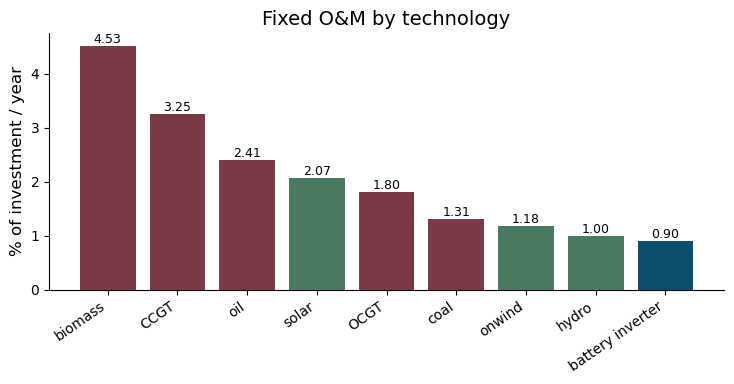

In [53]:
bar_compare("FOM", "% of investment / year", "Fixed O&M by technology", "05_fom")


saved figures/input_costs/05b_fom_eur.png


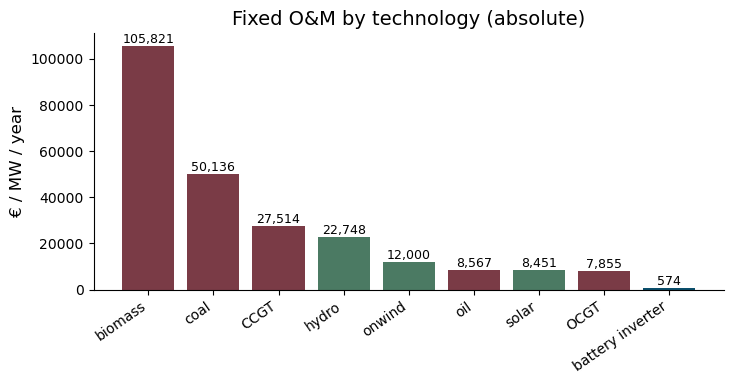

In [54]:
# FOM is published as a %/year of investment -- express it in absolute EUR/MW/year too,
# so it's directly comparable (and summable) with VOM and capital_cost elsewhere in this notebook.
sub["FOM_eur_per_year"] = sub["investment"] * sub["FOM"] / 100
bar_compare("FOM_eur_per_year", "€ / MW / year", "Fixed O&M by technology (absolute)", "05b_fom_eur", "{:,.0f}")


saved figures/input_costs/06_vom.png


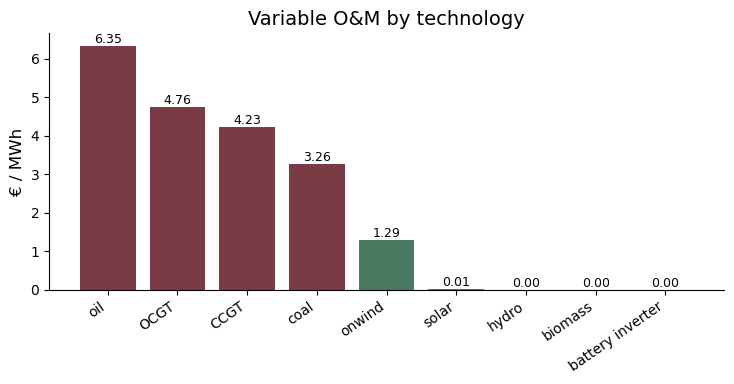

In [55]:
bar_compare("VOM", "€ / MWh", "Variable O&M by technology", "06_vom")


saved figures/input_costs/06b_fuel.png


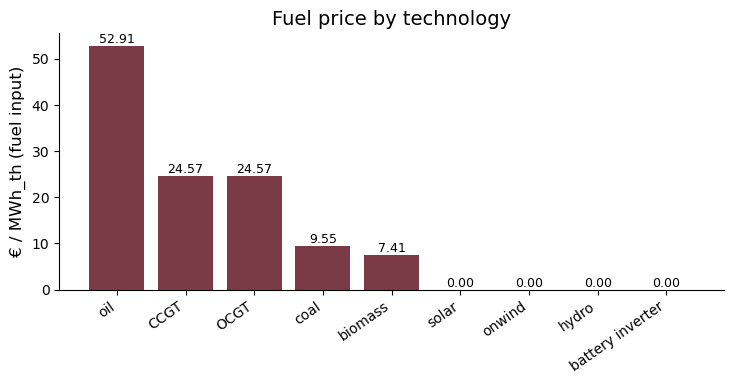

In [56]:
# Fuel price, EUR/MWh of fuel (thermal) input -- the other half of marginal_cost, before the
# efficiency conversion to electrical output. CCGT and OCGT share an identical value here since
# both are backfilled from the generic 'gas' technology row in process_cost_data.py.
bar_compare("fuel", "€ / MWh_th (fuel input)", "Fuel price by technology", "06b_fuel", "{:.2f}")


saved figures/input_costs/07_efficiency.png


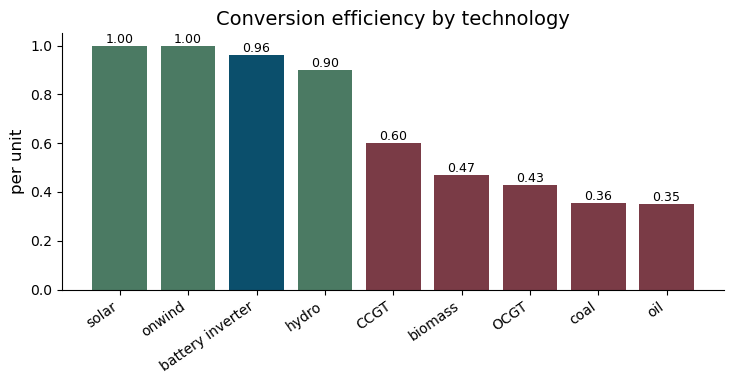

In [57]:
bar_compare("efficiency", "per unit", "Conversion efficiency by technology", "07_efficiency")


saved figures/input_costs/08_lifetime.png


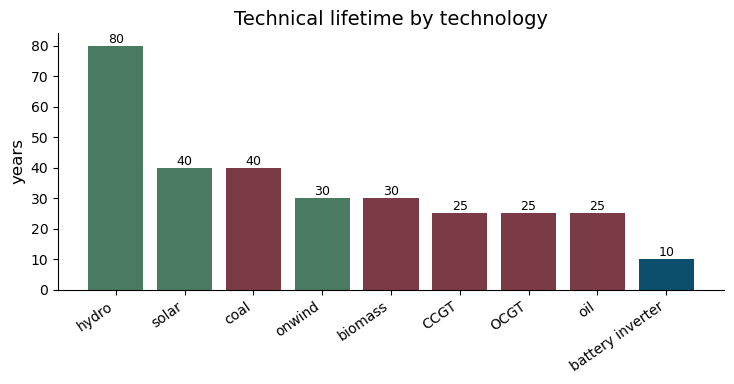

In [58]:
bar_compare("lifetime", "years", "Technical lifetime by technology", "08_lifetime", "{:.0f}")


saved figures/input_costs/09_capital_cost.png


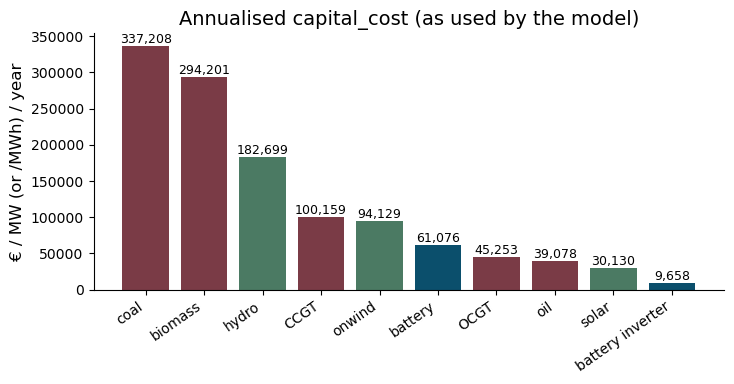

In [59]:
bar_compare("capital_cost", "€ / MW (or /MWh) / year", "Annualised capital_cost (as used by the model)", "09_capital_cost", "{:,.0f}")


saved figures/input_costs/10_marginal_cost.png


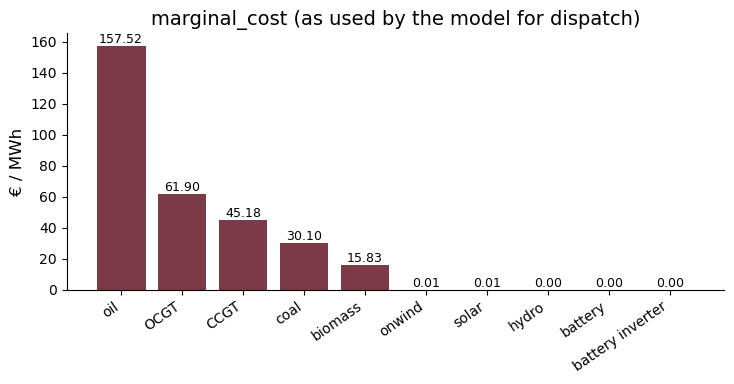

In [60]:
bar_compare("marginal_cost", "€ / MWh", "marginal_cost (as used by the model for dispatch)", "10_marginal_cost")


## 4. CAPEX Decomposition: Annuitised Investment + FOM vs. Reported `capital_cost`

`capital_cost` is supposed to already combine annuitised overnight `investment` and `FOM`
(the usual `technology-data` convention). This reconstructs it from the raw components to
sanity-check the two agree, on the **input** side (Section 5 of
`BESS_Cost_Structure_Analysis.ipynb` does the analogous check against the solved network).
`battery` is dropped here: its `investment`/`FOM`/`lifetime` fields are all `NaN` in this
file even though `capital_cost` itself is populated (61,076/MW/yr) — see the note below the plot.

In [61]:
rows = []
skipped = []
for c in RELEVANT_CARRIERS:
    row = sub.loc[c]
    if pd.isna(row["investment"]) or pd.isna(row["lifetime"]) or pd.isna(row["discount rate"]):
        skipped.append(c)
        continue
    annuitised_capex = row["investment"] * crf(row["discount rate"], row["lifetime"])
    fom_annual = row["investment"] * row["FOM"] / 100 if pd.notna(row["FOM"]) else 0
    rows.append({"technology": c, "annuitised_capex": annuitised_capex, "fom_annual": fom_annual,
                 "reconstructed_sum": annuitised_capex + fom_annual, "capital_cost_in_file": row["capital_cost"]})
decomp = pd.DataFrame(rows).set_index("technology")
decomp["pct_diff"] = 100 * (decomp["reconstructed_sum"] - decomp["capital_cost_in_file"]) / decomp["capital_cost_in_file"]
print(f"Skipped (missing investment/lifetime/discount rate): {skipped}")
decomp


Skipped (missing investment/lifetime/discount rate): ['battery']


,annuitised_capex,fom_annual,reconstructed_sum,capital_cost_in_file,pct_diff
technology,,,,,
solar,30657.540217,8450.640962,39108.181179,30129.873172,2.979869e+01
onwind,82128.625808,12000.344063,94128.969871,94128.969871,-1.545955e-14
hydro,159950.557592,22748.177000,182698.734592,182698.734592,0.000000e+00
CCGT,72645.235980,27513.762250,100158.998230,100158.998230,-1.452881e-14
OCGT,37397.767994,7854.747814,45252.515808,45252.515808,1.607857e-14
oil,30511.002029,8567.278437,39078.280467,39078.280467,0.000000e+00
coal,287072.193458,50135.833990,337208.027448,337208.027448,1.726165e-14
biomass,188379.711650,105821.339520,294201.051170,294201.051170,0.000000e+00
battery inverter,9084.254184,574.236000,9658.490184,9658.490184,-1.883306e-14


saved figures/input_costs/11_capex_decomposition.png


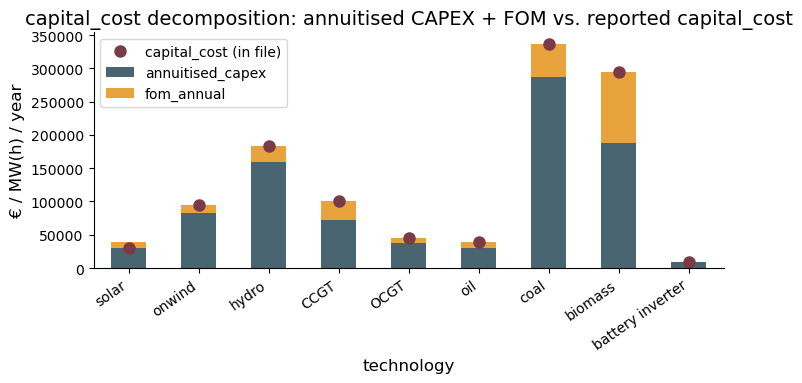

In [62]:
fig, ax = plt.subplots(figsize=(7.5, 4))
decomp[["annuitised_capex", "fom_annual"]].plot(kind="bar", stacked=True, ax=ax,
                                                  color=[PALETTE["slate"], PALETTE["amber"]])
ax.plot(range(len(decomp)), decomp["capital_cost_in_file"], "o", color=PALETTE["burgundy"],
        markersize=8, label="capital_cost (in file)")
ax.set_ylabel("€ / MW(h) / year")
ax.set_title("capital_cost decomposition: annuitised CAPEX + FOM vs. reported capital_cost")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
savefig(fig, "11_capex_decomposition")
plt.show()


## 5. Cost vs. Efficiency Trade-off

saved figures/input_costs/12_cost_vs_efficiency_scatter.png


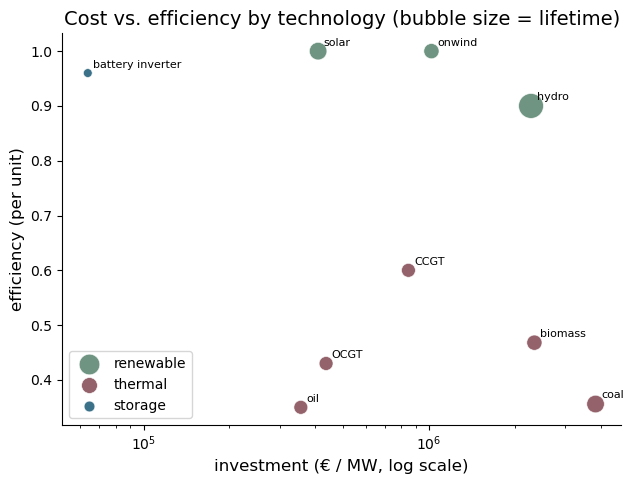

In [63]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for cat, color in CATEGORY_COLORS.items():
    d = sub[sub.category == cat]
    x = d["investment"].astype(float)
    y = d["efficiency"].astype(float)
    s = d["lifetime"].astype(float).fillna(20) * 4
    ax.scatter(x, y, s=s, color=color, alpha=0.8, label=cat, edgecolor="white", linewidth=0.5)
    for name, xi, yi in zip(d.index, x, y):
        if pd.notna(xi) and pd.notna(yi):
            ax.annotate(name, (xi, yi), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("investment (€ / MW, log scale)")
ax.set_ylabel("efficiency (per unit)")
ax.set_title("Cost vs. efficiency by technology (bubble size = lifetime)")
ax.legend()
savefig(fig, "12_cost_vs_efficiency_scatter")
plt.show()


## 6. Cross-Parameter Correlation (Full Catalogue)

Uses all technologies with these columns populated (not just the 10 relevant carriers) since
10 points is too few to say anything statistically meaningful about correlation.

saved figures/input_costs/13_correlation_heatmap.png


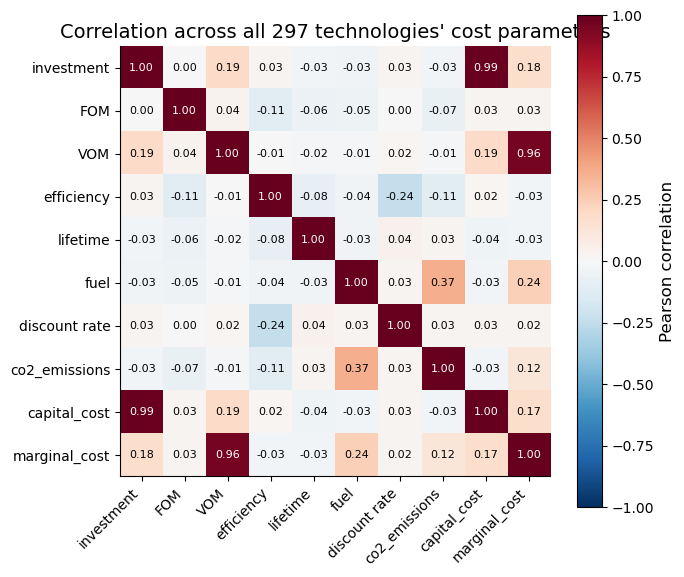

In [64]:
numeric_cols = ["investment", "FOM", "VOM", "efficiency", "lifetime", "fuel", "discount rate",
                "co2_emissions", "capital_cost", "marginal_cost"]
corr = elec[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        v = corr.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if abs(v) > 0.5 else "black")
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title(f"Correlation across all {len(elec)} technologies' cost parameters")
savefig(fig, "13_correlation_heatmap")
plt.show()


## 7. Battery Deep-Dive: Is PyPSA-Earth's Default "battery" a Reasonable Assumption?

The model represents your BESS with two generic technology-data entries, `battery` (energy,
€/MWh/yr) and `battery inverter` (power, €/MW/yr) — see the "Battery Storage" vs. "battery
charger" discussion earlier in `BESS_Cost_Structure_Analysis.ipynb`. `technology-data` also
ships cost assumptions for ~20 other storage chemistries/technologies (Lithium-Ion-LFP,
Vanadium-Redox-Flow, Pumped-Storage-Hydro, ...). Comparing the generic entry against that full
storage landscape is directly relevant for a BESS thesis: it tells you whether "battery" is a
conservative, typical, or optimistic proxy for what you're actually modelling.

saved figures/input_costs/14_storage_energy_cost_comparison.png


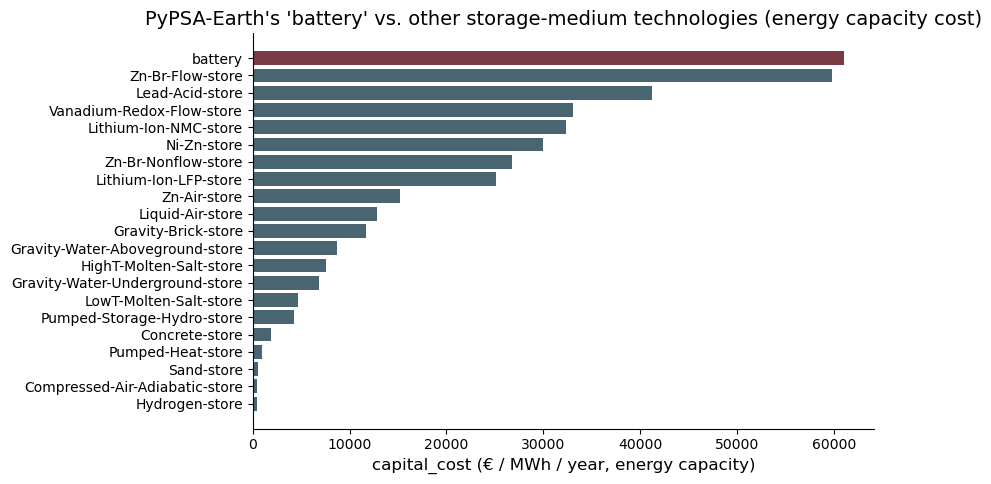

'battery' ranks #1 of 21 storage-medium technologies by capital_cost (most expensive).


In [65]:
store_techs = [t for t in elec.index if t.endswith("-store") or t == "battery"]
charger_techs = [t for t in elec.index if t.endswith("-bicharger") or t == "battery inverter"]

fig, ax = plt.subplots(figsize=(9, 5))
vals = elec.loc[store_techs, "capital_cost"].dropna().sort_values()
colors = [PALETTE["burgundy"] if t == "battery" else PALETTE["slate"] for t in vals.index]
ax.barh(vals.index, vals.values, color=colors)
ax.set_xlabel("capital_cost (€ / MWh / year, energy capacity)")
ax.set_title("PyPSA-Earth's 'battery' vs. other storage-medium technologies (energy capacity cost)")
savefig(fig, "14_storage_energy_cost_comparison")
plt.show()

rank = (vals.rank(ascending=False).loc["battery"])
print(f"'battery' ranks #{int(rank)} of {len(vals)} storage-medium technologies by capital_cost "
      f"({'most' if rank == 1 else f'{int(rank)}th most'} expensive).")


saved figures/input_costs/15_storage_power_cost_comparison.png


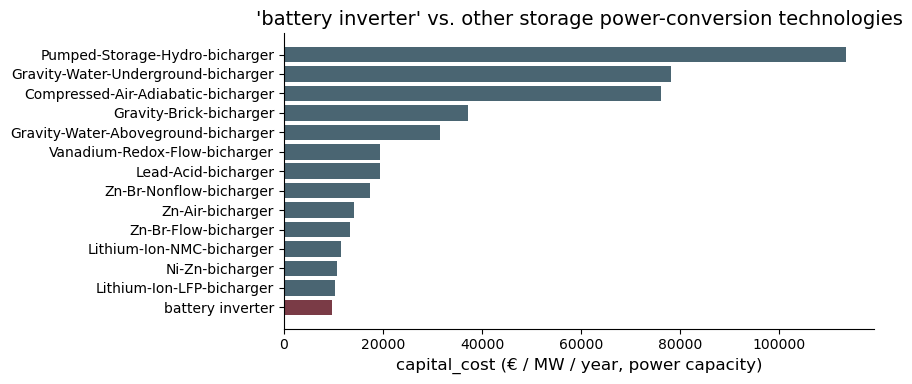

'battery inverter' ranks #14 of 14 power-conversion technologies by capital_cost (14th most expensive).


In [66]:
fig, ax = plt.subplots(figsize=(9, 4))
vals = elec.loc[charger_techs, "capital_cost"].dropna().sort_values()
colors = [PALETTE["burgundy"] if t == "battery inverter" else PALETTE["slate"] for t in vals.index]
ax.barh(vals.index, vals.values, color=colors)
ax.set_xlabel("capital_cost (€ / MW / year, power capacity)")
ax.set_title("'battery inverter' vs. other storage power-conversion technologies")
savefig(fig, "15_storage_power_cost_comparison")
plt.show()

rank = (vals.rank(ascending=False).loc["battery inverter"])
print(f"'battery inverter' ranks #{int(rank)} of {len(vals)} power-conversion technologies by "
      f"capital_cost ({'most' if rank == 1 else f'{int(rank)}th most'} expensive).")


## 8. Category Roll-Up & Export

saved figures/input_costs/16_category_grouping.png


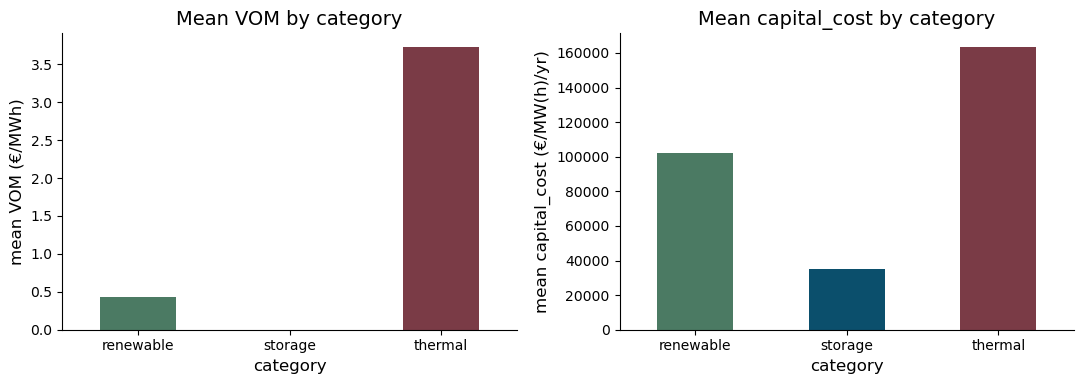

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cat_group = sub.groupby("category")[["VOM", "capital_cost"]].mean()
cat_group["VOM"].plot(kind="bar", ax=axes[0], color=[CATEGORY_COLORS[c] for c in cat_group.index])
axes[0].set_ylabel("mean VOM (€/MWh)")
axes[0].set_title("Mean VOM by category")
cat_group["capital_cost"].plot(kind="bar", ax=axes[1], color=[CATEGORY_COLORS[c] for c in cat_group.index])
axes[1].set_ylabel("mean capital_cost (€/MW(h)/yr)")
axes[1].set_title("Mean capital_cost by category")
for a in axes:
    plt.setp(a.get_xticklabels(), rotation=0)
savefig(fig, "16_category_grouping")
plt.show()


In [68]:
summary_cols = ["category", "investment", "FOM", "VOM", "efficiency", "lifetime",
                "discount rate", "fuel", "co2_emissions", "capital_cost", "marginal_cost"]
sub[summary_cols].to_csv(FIG_DIR / "relevant_carriers_cost_summary.csv")
print(f"saved {FIG_DIR / 'relevant_carriers_cost_summary.csv'}")
sub[summary_cols]


saved figures/input_costs/relevant_carriers_cost_summary.csv


,category,investment,FOM,VOM,efficiency,lifetime,discount rate,fuel,co2_emissions,capital_cost,marginal_cost
technology,,,,,,,,,,,
solar,renewable,408717.4,2.0676,0.0106,1.000,40.0,0.07,0.0000,0.0000,30129.873172,0.010000
onwind,renewable,1019137.5,1.1775,1.2857,1.000,30.0,0.07,0.0000,0.0000,94128.969871,0.015000
hydro,renewable,2274817.7,1.0000,0.0000,0.900,80.0,0.07,0.0000,0.0000,182698.734592,0.000000
CCGT,thermal,846577.3,3.2500,4.2329,0.600,25.0,0.07,24.5680,0.1980,100158.998230,45.179567
OCGT,thermal,435818.0,1.8023,4.7620,0.430,25.0,0.07,24.5680,0.1980,45252.515808,61.896884
oil,thermal,355562.5,2.4095,6.3493,0.350,25.0,0.07,52.9111,0.2571,39078.280467,157.523871
coal,thermal,3827162.9,1.3100,3.2612,0.356,40.0,0.07,9.5542,0.3361,337208.027448,30.098840
biomass,thermal,2337611.6,4.5269,0.0000,0.468,30.0,0.07,7.4076,0.0000,294201.051170,15.828205
battery,storage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,61075.839080,0.000000
